# Part II: Autoencoders for Anomaly Detection [30 pts]
Implement autoencoder and explore its application for a real-world problem related to anomaly detection.
The final model should achieve a test accuracy of greater than 80%.

**Datasets:** Select ONE dataset based on your preference:
- Yahoo S5 Dataset
- Hard Drive Test Data
- Numenta Anomaly Benchmark

## Step 1: Data preparation

1. Select and load one dataset from the list above.

<span style='color:green'>### YOUR ANSWER ###</span>


Dataset chosen - Numenta Anomaly Benchmark
CSV in chosen dataset - Twitter_volume_AAPL.csv</span>

2. Analyze the dataset and provide the following statistics:
   - Number of samples (time points)
   - Number of features
   - Mean, standard deviation, minimum, and maximum values for each feature (or relevant descriptive statistics depending on the data type)

In [4]:
!pip install torchinfo
!pip install torch

In [5]:
### ADD YOUR CODE HERE ###
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from torch.utils.data import DataLoader
from torch.utils.data import DataLoader, TensorDataset, Dataset
import torch
import torch.nn as nn
import torch.optim as optim
from torchinfo import summary

# load the dataset
data = pd.read_csv('Twitter_volume_AAPL.csv')

# dataset analysis
#basic info, mean, std dev, min, max
print("Dataset Information:")
print(data.info())
print("\nDescriptive Statistics:")
print(data.describe())

# number of samples (time points) and features
num_samples = data.shape[0]
num_features = data.shape[1]
print(f"\nNumber of samples (time points): {num_samples}")
print(f"Number of features: {num_features}")



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15902 entries, 0 to 15901
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   timestamp  15902 non-null  object
 1   value      15902 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 248.6+ KB
None

Descriptive Statistics:
              value
count  15902.000000
mean      85.552320
std      321.050721
min        0.000000
25%       29.000000
50%       47.000000
75%       76.000000
max    13479.000000

Number of samples (time points): 15902
Number of features: 2


Provide a brief description (2-3 sentences) of the dataset: What does it represent? Where does it come from (provide a link)? What are the key variables?

<span style='color:green'>### YOUR ANSWER ###</span>


#Dataset description
*   The Twitter_volume_AAPL.csv dataset contains time-series data related to the volume of tweets mentioning Apple (AAPL) stocks.
*   It is part of the Numenta Anomaly Benchmark (NAB)
*   The Numenta Anomaly Benchmark (NAB) is an open source framework designed to test algorithms for detecting anomalies in streaming data
*   The key features in this dataset include the timestamp of each data point and the volume of tweets related to AAPL stock at that specific time.
*   Link - https://www.kaggle.com/datasets/boltzmannbrain/nab/
In this dataset, go to archive\realTweets\realTweets





3. Create at least three different visualizations to explore the dataset. Provide a short description explaining what each visualization shows.

Visualization and a short description # 1

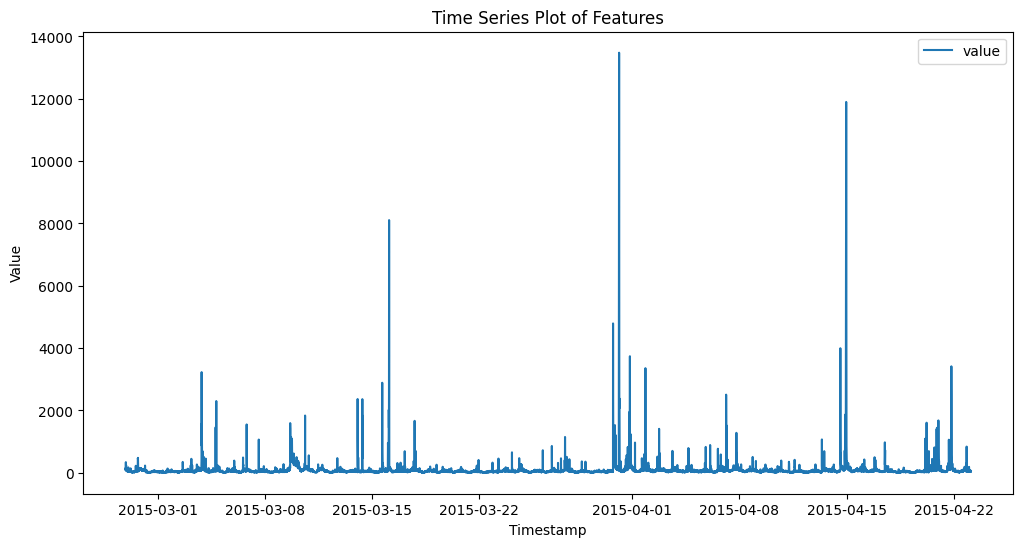

In [6]:
### ADD YOUR CODE HERE ###
# time series plot

data['timestamp'] = pd.to_datetime(data['timestamp'])
plt.figure(figsize=(12, 6))
for col in data.columns:
    if col != 'timestamp':
        plt.plot(data['timestamp'], data[col], label=col)
plt.xlabel('Timestamp')
plt.ylabel('Value')
plt.title('Time Series Plot of Features')
plt.legend()
plt.show()

<span style='color:green'>### YOUR ANSWER ###

*   This time series plot shows daily Twitter volume for AAPL from March 1, 2015 to April 22, 2015.
*   There are multiple sharp spikes in tweet volume, indicating significant market events, news, or certain events related to Apple during those times, for example, on 2015-04-01, there is a significant sharp spike


*   The general volume remains low with occasional bursts, suggesting that most days see relatively stable discussion, but certain events trigger sigificant user engagement.

</span>

Visualization and a short description # 2

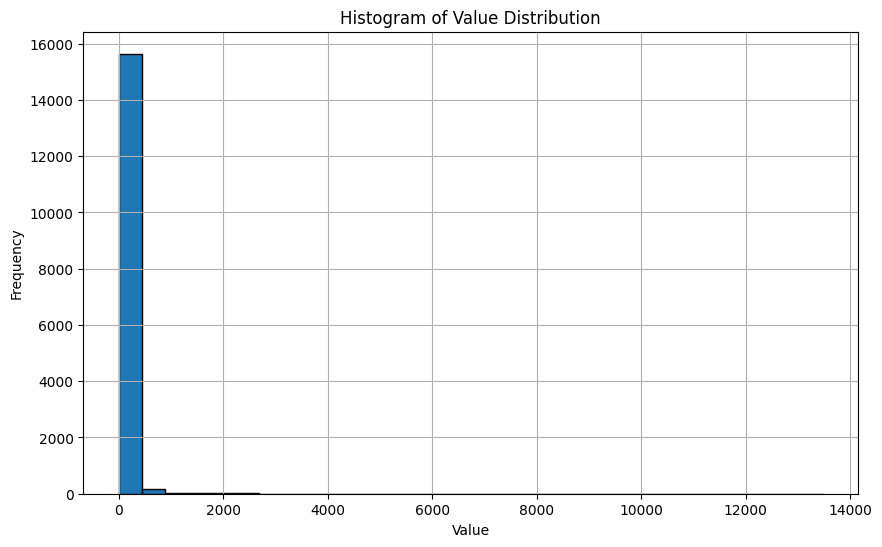

In [7]:
### ADD YOUR CODE HERE ###
# histogram of value column distribution
plt.figure(figsize=(10, 6))
data['value'].hist(bins=30, edgecolor='black')
plt.title('Histogram of Value Distribution')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

<span style='color:green'>### YOUR ANSWER ###

*   The majority of Twitter volume values are very low, concentrated near zero.

*   There are a few extreme outliers (high-value tweets) causing a long right tail, that extends a little after 2000 on the x-axis

*   The skewed distribution suggests rare but significant spikes in tweet activity, likely corresponding to major events.



</span>

Visualization and a short description # 3

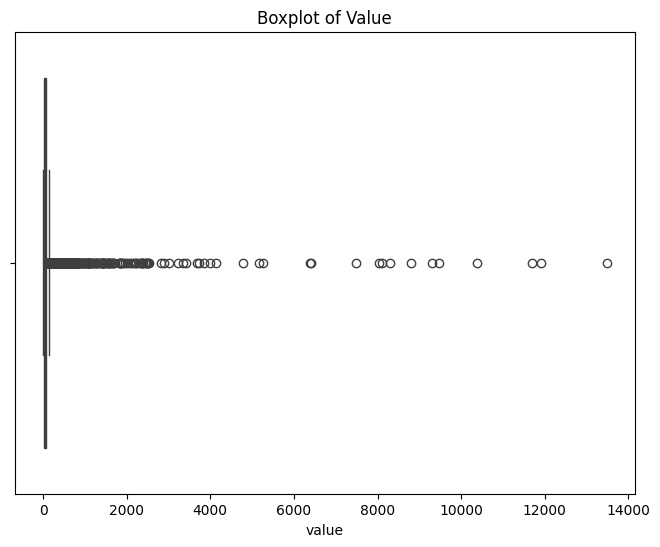

In [8]:
### ADD YOUR CODE HERE ###
#box plot for outlier detection
plt.figure(figsize=(8, 6))
sns.boxplot(x=data['value'])
plt.title('Boxplot of Value')
plt.show()


<span style='color:green'>### YOUR ANSWER ###</span>


*   This boxplot visualizes the distribution of tweet volumes related to AAPL
*   The majority of values are concentrated near the lower end, while the circles represent outliers—unusually high tweet volumes.



4. Identify any missing values (e.g. using pandas.isnull().sum()). Handle any missing values (imputation or removal). Common imputation methods include: forward/backward fill, mean/median imputation, linear interpolation).

In [9]:
### ADD YOUR CODE HERE ###
# identify and handle missing values
print("Missing values in each column before imputation:")
print(data.isnull().sum())

# impute missing values using forward fill, backward fill
data.fillna(method='ffill', inplace=True)
data.fillna(method='bfill', inplace=True)




Missing values in each column before imputation:
timestamp    0
value        0
dtype: int64


<ipython-input-9-70ec9b49a639>:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True)
<ipython-input-9-70ec9b49a639>:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='bfill', inplace=True)


5. Preprocess the dataset.

   a. Normalize the data.

In [10]:
# data normalization
numeric_cols = data.select_dtypes(include=[np.number]).columns
scaler = StandardScaler()
data[numeric_cols] = scaler.fit_transform(data[numeric_cols])


   b. [If needed] Address class imbalance in the target column. Possible solutions: oversampling; undersampling; data augmentation techniques for the minority class; assign higher weights to the minority class and lower weights to the majority class, etc.

In [11]:
### ADD YOUR CODE HERE ###

#no class imbalance to be addressed here as we are working with time series data with continuous values (tweet volume) — not categorical classes.
#Class imbalance techniques apply to classification problems



   c. [If needed] Convert target variable needs to numerical format. You can use one-hot encoding. However, if you use torch.nn.CrossEntropyLoss for your network, it expects class indices (0, 1, 2) directly, not one-hot encoded vectors. Therefore, ensure your labels are integer tensors (e.g., torch.LongTensor).

In [12]:
### ADD YOUR CODE HERE ###

#target variable is numeric (tweet volume), not categorical
#no need to convert target variable to numerical format for anomaly detection


6. Split the dataset into training, testing and validation sets. You can use train_test_split from scikit-learn.

In [13]:
### ADD YOUR CODE HERE ###

train_data, test_data = train_test_split(data, test_size=0.2, shuffle=False)

# further split training data into training and validation sets
train_data, val_data = train_test_split(train_data, test_size=0.2, shuffle=False)

# print shape of the splits
print(f"Training Set Shape: {train_data.shape}")
print(f"Validation Set Shape: {val_data.shape}")
print(f"Test Set Shape: {test_data.shape}")


Training Set Shape: (10176, 2)
Validation Set Shape: (2545, 2)
Test Set Shape: (3181, 2)


## Step 2: Autoencoder model building

1. Choose and implement one of the following: Autoencoder,Variational Autoencoder (VAE) or other version of Autoencoder for anomaly detection.

2. Experiment with different architectures. Build and train 3 different autoencoder architectures for anomaly detection. Consider experimenting with:
   - Different layer types (Dense, LSTM for time series, Conv1D for sequential data)
   - Number of hidden layers and units
   - Activation functions (ReLU, sigmoid)
   - Print model summary using torchinfo.summary

### Model 1 Architecture ###

In [14]:
!pip install torchinfo

In [15]:
### ADD YOUR CODE HERE ###

# define the Convolutional Autoencoder architecture
class ConvAutoencoder(nn.Module):
    def __init__(self):
        super(ConvAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv1d(16, 8, kernel_size=3, stride=2, padding=1),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(8, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose1d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

### Model 2 Architecture ###

In [16]:
### ADD YOUR CODE HERE ###
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchinfo
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets

class VAE_Autoencoder(nn.Module):
  def __init__(self, input_dim, latent_dim):
    super(VAE_Autoencoder, self).__init__()

    # Encoder layers
    self.encoder = nn.Sequential(
      nn.Linear(input_dim, 256),
      nn.ReLU(),
      nn.Linear(256, 128),
      nn.ReLU(),
      nn.Linear(128, latent_dim * 2)  # Output mean and log_var
    )

    # self.mu_layer = nn.Linear(latent_dim,2),
    # self.log_var_layer = nn.Linear(latent_dim,2)

    # Decoder layers
    self.decoder = nn.Sequential(
      nn.Linear(latent_dim, 128),
      nn.ReLU(),
      nn.Linear(128, 256),
      nn.ReLU(),
      nn.Linear(256, input_dim),
      nn.Sigmoid()
    )

  def encode(self, x):
    # x = x.view(x.size(0), -1)
    # print(f"Flattened input shape: {x.shape}")
    h = self.encoder(x)
    mu, log_var =  h[:, :latent_dim], h[:, latent_dim:]
    return mu, log_var

  def reparameterize(self, mu, log_var):
    std = torch.exp(0.5 * log_var)
    eps = torch.randn_like(std)
    return mu + eps * std

  def decode(self, z):
    return self.decoder(z)

  def forward(self, x):
    mu, log_var = self.encode(x)
    z = self.reparameterize(mu, log_var)
    return self.decode(z), mu, log_var

#loss function
def loss_function(x_recon, x, mu, log_var):
  # Reconstruction loss with MSE as we have continous data
  recon_loss = nn.MSELoss()(x_recon, x)       #nn.BCELoss(reduction='sum')(x_recon, x)

  # KL Divergence loss
  kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())

  return recon_loss + kl_loss


### Model 3 Architecture ###

In [17]:
### ADD YOUR CODE HERE ###
class VAE_LSTM_AutoEncoder(nn.Module):
  def __init__(self, input_dim, latent_dim):
    super(VAE_LSTM_AutoEncoder, self).__init__()

    # Encoder with LSTM layers
    self.lstm_encoder = nn.LSTM(input_dim, 64, batch_first=True)
    self.fc_mu = nn.Linear(64, latent_dim)
    self.fc_logvar = nn.Linear(64, latent_dim)

    # Decoder with LSTM layers
    # self.fc_latent = nn.Linear(latent_dim, 128)
    self.lstm_decoder = nn.LSTM(latent_dim, 64, batch_first=True)
    self.fc_out = nn.Linear(64, input_dim)

  def encode(self, x):
    _, (h_n, _) = self.lstm_encoder(x)
    mu = self.fc_mu(h_n[-1])
    log_var = self.fc_logvar(h_n[-1])
    return mu, log_var

  def reparameterize(self, mu, log_var):
    std = torch.exp(0.5 * log_var)
    eps = torch.randn_like(std)
    return mu + eps * std

  def decode(self, z, seq_len):
    z = z.unsqueeze(1).repeat(1, seq_len, 1)
    out, _ = self.lstm_decoder(z)
    return self.fc_out(out)

  def forward(self, x):

    #encoder forward pass
    mu, log_var = self.encode(x)
    z = self.reparameterize(mu, log_var)

    # Decoder forward pass
    seq_len = x.size(1)  #inpue sequence length
    recon_batch = self.decode(z, seq_len)

    return recon_batch, mu, log_var



3. Model training and hyperparameter tuning:
   - Choose an appropriate loss function and optimizer (e.g., Adam).
   - Train your model and monitor its performance on the training and validation sets.
   - Tune hyperparameters (learning rate, batch size, number of epochs, hidden units, dropout rate) using the validation set.
   - Plot the training and validation loss and accuracy curves over epochs. Analyze the plots for signs of overfitting or underfitting. Adjust your model or hyperparameters if needed.

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Training Model #1

In [19]:
### ADD YOUR CODE HERE ###
# sliding window function to create sequences from the time series
def create_sequences(data, window_size):
    sequences = []
    # Assuming the time series column is named 'value'
    values = data['value'].values
    for i in range(len(values) - window_size + 1):
        seq = values[i:i+window_size]
        sequences.append(seq)
    return np.array(sequences)

# set window size
window_size = 30

# create sequences for train, validation, and test sets
train_sequences = create_sequences(train_data, window_size)
val_sequences = create_sequences(val_data, window_size)
test_sequences = create_sequences(test_data, window_size)

# create a custom PyTorch Dataset
class TimeSeriesDataset(Dataset):
    def __init__(self, sequences):
        self.sequences = sequences

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq = self.sequences[idx]
        seq = torch.tensor(seq, dtype=torch.float32).unsqueeze(0)
        return seq, seq

# instantiate datasets and dataloaders
train_dataset = TimeSeriesDataset(train_sequences)
val_dataset = TimeSeriesDataset(val_sequences)
test_dataset = TimeSeriesDataset(test_sequences)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

model = ConvAutoencoder()

# loss function, and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# print model summary using torchinfo
torchinfo.summary(model, input_size=(batch_size, 1, window_size))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)



ConvAutoencoder(
  (encoder): Sequential(
    (0): Conv1d(1, 16, kernel_size=(3,), stride=(2,), padding=(1,))
    (1): ReLU()
    (2): Conv1d(16, 8, kernel_size=(3,), stride=(2,), padding=(1,))
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose1d(8, 16, kernel_size=(3,), stride=(2,), padding=(1,), output_padding=(1,))
    (1): ReLU()
    (2): ConvTranspose1d(16, 1, kernel_size=(3,), stride=(2,), padding=(1,), output_padding=(1,))
    (3): Sigmoid()
  )
)

Epoch 1/20, Train Loss: 0.891934, Val Loss: 0.079149
Epoch 2/20, Train Loss: 0.718994, Val Loss: 0.065626
Epoch 3/20, Train Loss: 0.712480, Val Loss: 0.062610
Epoch 4/20, Train Loss: 0.710124, Val Loss: 0.060999
Epoch 5/20, Train Loss: 0.708944, Val Loss: 0.060235
Epoch 6/20, Train Loss: 0.708302, Val Loss: 0.059685
Epoch 7/20, Train Loss: 0.707860, Val Loss: 0.059224
Epoch 8/20, Train Loss: 0.707511, Val Loss: 0.058833
Epoch 9/20, Train Loss: 0.707145, Val Loss: 0.058372
Epoch 10/20, Train Loss: 0.706696, Val Loss: 0.057853
Epoch 11/20, Train Loss: 0.706248, Val Loss: 0.057324
Epoch 12/20, Train Loss: 0.705876, Val Loss: 0.056862
Epoch 13/20, Train Loss: 0.705502, Val Loss: 0.056389
Epoch 14/20, Train Loss: 0.705098, Val Loss: 0.056021
Epoch 15/20, Train Loss: 0.704881, Val Loss: 0.055860
Epoch 16/20, Train Loss: 0.704796, Val Loss: 0.055734
Epoch 17/20, Train Loss: 0.704731, Val Loss: 0.055662
Epoch 18/20, Train Loss: 0.704674, Val Loss: 0.055607
Epoch 19/20, Train Loss: 0.704623, Va

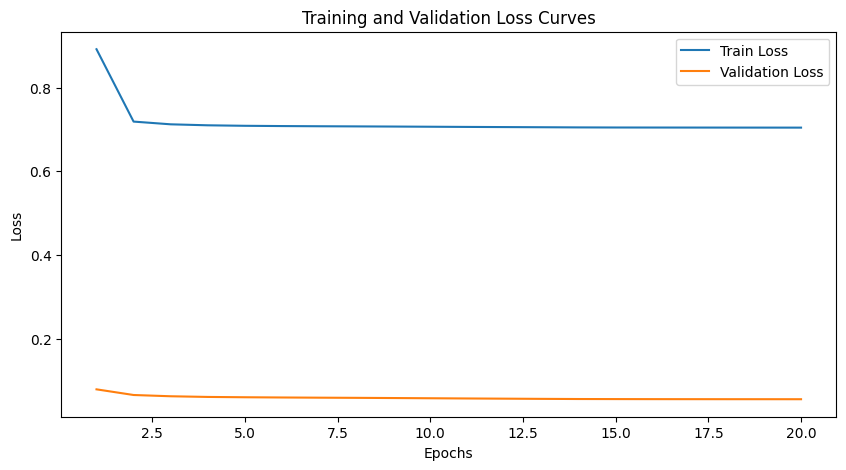

In [20]:
# Training loop
num_epochs = 20
train_losses = []
val_losses = []
best_val_loss = np.inf

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        if outputs.shape[2] != targets.shape[2]:
          outputs = outputs[:, :, :targets.shape[2]]
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            outputs = model(inputs)
            if outputs.shape[2] != targets.shape[2]:
              outputs = outputs[:, :, :targets.shape[2]]

            loss = criterion(outputs, targets)
            running_loss += loss.item() * inputs.size(0)
    epoch_val_loss = running_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {epoch_train_loss:.6f}, Val Loss: {epoch_val_loss:.6f}")

    # save model weights if this epoch produces the best validation loss so far
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), 'best_conv_autoencoder.pth')

# plot the training and validation loss curves
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curves')
plt.legend()
plt.show()


Training Model #2

In [21]:
### ADD YOUR CODE HERE ###
import numpy as np

#using code from assignment 1 part 3 a1_part3_ra65_hsingh47.ipynb
def create_sequences_vae(data, seq_length):
  xs = []
  # ys = [] not necessary for anomoly detection
  for i in range(len(data) - seq_length):
      x = data[i:(i + seq_length)]
      # y = data[i + seq_length]
      xs.append(x)
      # ys.append(y)
  return np.array(xs) #, np.array(ys)

sequence_length = 30

# input_dim = train_data[numeric_cols].shape[1]
# print(input_dim)

train_sequences = create_sequences_vae(train_data[numeric_cols].values, sequence_length)
val_sequences = create_sequences_vae(val_data[numeric_cols].values, sequence_length)
test_sequences = create_sequences_vae(test_data[numeric_cols].values, sequence_length)

# print(train_data[numeric_cols].values)
print(f"Train data shape: {train_sequences.shape}")


train_tensor = torch.tensor(train_sequences, dtype=torch.float32)
val_tensor = torch.tensor(val_sequences, dtype=torch.float32)
test_tensor = torch.tensor(test_sequences, dtype=torch.float32)


# train_tensor = torch.tensor(train_data[numeric_cols].values, dtype=torch.float32)
# val_tensor = torch.tensor(val_data[numeric_cols].values, dtype=torch.float32)
# test_tensor = torch.tensor(test_data[numeric_cols].values, dtype=torch.float32)

# print(train_data[numeric_cols].values)
# print(train_tensor)
print(f"Train tensor shape: {train_tensor.shape}")

#batch size
batch_size = 32

# Create DataLoaders
train_loader = DataLoader(TensorDataset(train_tensor), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(val_tensor), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(test_tensor), batch_size=batch_size, shuffle=False)

learning_rate = 1e-3
epochs = 20
input_dim=train_tensor.shape[1]   #based on the features
latent_dim=2

print(train_tensor.shape)

# Initialize model, optimizer
model_vae = VAE_Autoencoder(input_dim=input_dim, latent_dim=latent_dim).to(device)
optimizer_vae = optim.Adam(model_vae.parameters(), lr=learning_rate)

# Model summary
torchinfo.summary(model_vae, input_size=(batch_size, input_dim))

Train data shape: (10146, 30, 1)
Train tensor shape: torch.Size([10146, 30, 1])
torch.Size([10146, 30, 1])


Layer (type:depth-idx)                   Output Shape              Param #
VAE_Autoencoder                          [32, 30]                  --
├─Sequential: 1-1                        [32, 4]                   --
│    └─Linear: 2-1                       [32, 256]                 7,936
│    └─ReLU: 2-2                         [32, 256]                 --
│    └─Linear: 2-3                       [32, 128]                 32,896
│    └─ReLU: 2-4                         [32, 128]                 --
│    └─Linear: 2-5                       [32, 4]                   516
├─Sequential: 1-2                        [32, 30]                  --
│    └─Linear: 2-6                       [32, 128]                 384
│    └─ReLU: 2-7                         [32, 128]                 --
│    └─Linear: 2-8                       [32, 256]                 33,024
│    └─ReLU: 2-9                         [32, 256]                 --
│    └─Linear: 2-10                      [32, 30]                  7,710

In [22]:
best_validation_loss = float('inf')
best_epoch = 0
train_losses_vae = []
validation_loss_vae = []
train_accuracy_vae = []
validation_accuracy_vae = []
reconstruction_errors_vae = []
train_reconstruction_losses_vae = []
val_reconstruction_losses_vae = []

threshold = 0.5


for epoch in range(epochs):

  model_vae.train()
  train_loss = 0
  correct_train = 0
  total_train = 0
  total_reconstruction_loss = 0

  for data_value in train_loader:
    data_value = data_value[0]
    data_value = data_value.view(data_value.size(0), -1)
    data_value = data_value.to(device)
    optimizer_vae.zero_grad()

    # Forward pass
    recon_batch, mu, log_var = model_vae(data_value)

    # calculate reconstruction error (mse)
    recon_error = torch.mean((data_value - recon_batch) ** 2, dim=1)
    total_reconstruction_loss += recon_error.sum().item()
    # reconstruction_errors.append(recon_error.detach().cpu().numpy())

    # Calculate loss
    loss = loss_function(recon_batch, data_value, mu, log_var)
    loss.backward()
    optimizer_vae.step()

    train_loss += loss.item()

    # accuracy based on reconstruction error where samples with error < threshold
    correct_train += (recon_error < threshold).sum().item()
    total_train += recon_error.size(0)


  avg_train_loss = train_loss / len(train_loader)
  train_losses_vae.append(avg_train_loss)
  train_accuracy_vae.append(correct_train / total_train)
  avg_reconstruction_loss_train = total_reconstruction_loss / len(train_loader)
  train_reconstruction_losses_vae.append(avg_reconstruction_loss_train)

  # Validation step
  model_vae.eval()
  val_loss = 0
  correct_val = 0
  total_val = 0
  total_reconstruction_loss_val = 0

  with torch.no_grad():
    for data_value in val_loader:
      data_value = data_value[0]
      data_value = data_value.view(-1, input_dim)
      data_value = data_value.to(device)

      recon_batch, mu, log_var = model_vae(data_value)

      loss = loss_function(recon_batch, data_value, mu, log_var)
      val_loss += loss.item()

      #Calculate reconstruction error in val loop
      recon_error = torch.mean((data_value - recon_batch) ** 2, dim=1)
      total_reconstruction_loss_val += recon_error.sum().item()

      # Calculate accuracy based on reconstruction error
      correct_val += (recon_error < threshold).sum().item()
      total_val += recon_error.size(0)

  avg_val_loss = val_loss / len(val_loader)
  validation_loss_vae.append(avg_val_loss)
  validation_accuracy_vae.append(correct_val / total_val)
  avg_reconstruction_loss_val = total_reconstruction_loss_val / len(val_loader)
  val_reconstruction_losses_vae.append(avg_reconstruction_loss_val)

  # print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Train Accuracy: {train_accuracy[-1]:.4f}, " f"Validation Loss: {avg_val_loss:.4f}, Validation Accuracy: {validation_accuracy[-1]:.4f}")
  print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Train Accuracy: {train_accuracy_vae[-1]:.4f}, "
  f"Train Reconstruction Loss: {avg_reconstruction_loss_train:.4f}, "
  f"Validation Loss: {avg_val_loss:.4f}, Validation Accuracy: {validation_accuracy_vae[-1]:.4f}, "
  f"Validation Reconstruction Loss: {avg_reconstruction_loss_val:.4f}")

Epoch 1/20, Train Loss: 1.0399, Train Accuracy: 0.9330, Train Reconstruction Loss: 27.2867, Validation Loss: 0.1093, Validation Accuracy: 0.9734, Validation Reconstruction Loss: 3.3333
Epoch 2/20, Train Loss: 0.8623, Train Accuracy: 0.9333, Train Reconstruction Loss: 26.9340, Validation Loss: 0.1057, Validation Accuracy: 0.9734, Validation Reconstruction Loss: 3.3313
Epoch 3/20, Train Loss: 0.8513, Train Accuracy: 0.9333, Train Reconstruction Loss: 26.9339, Validation Loss: 0.1045, Validation Accuracy: 0.9734, Validation Reconstruction Loss: 3.3302
Epoch 4/20, Train Loss: 0.8432, Train Accuracy: 0.9332, Train Reconstruction Loss: 26.9333, Validation Loss: 0.1044, Validation Accuracy: 0.9734, Validation Reconstruction Loss: 3.3300
Epoch 5/20, Train Loss: 0.8422, Train Accuracy: 0.9332, Train Reconstruction Loss: 26.9335, Validation Loss: 0.1043, Validation Accuracy: 0.9734, Validation Reconstruction Loss: 3.3297
Epoch 6/20, Train Loss: 0.8421, Train Accuracy: 0.9332, Train Reconstructio

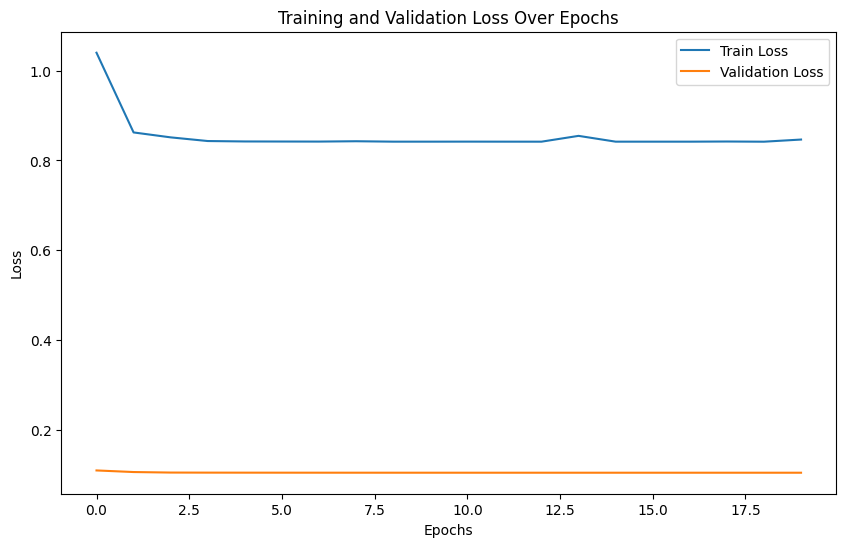

In [23]:
# Training and Validation Loss graph
plt.figure(figsize=(10, 6))
plt.plot(train_losses_vae, label='Train Loss')
plt.plot(validation_loss_vae, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.show()

Training model #3

In [24]:
### ADD YOUR CODE HERE ###
import numpy as np

#using code from assignment 1 part 3 a1_part3_ra65_hsingh47.ipynb
def create_sequences_lstm(data, seq_length):
  xs = []
  # ys = [] not necessary for anomoly detection
  for i in range(len(data) - seq_length):
      x = data[i:(i + seq_length)]
      # y = data[i + seq_length]
      xs.append(x)
      # ys.append(y)
  return np.array(xs) #, np.array(ys)

sequence_length = 30

# input_dim = train_data[numeric_cols].shape[1]
# print(input_dim)

train_sequences = create_sequences_lstm(train_data[numeric_cols].values, sequence_length)
val_sequences = create_sequences_lstm(val_data[numeric_cols].values, sequence_length)
test_sequences = create_sequences_lstm(test_data[numeric_cols].values, sequence_length)

# print(train_data[numeric_cols].values)
print(f"Train data shape: {train_sequences.shape}")


train_tensor = torch.tensor(train_sequences, dtype=torch.float32)
val_tensor = torch.tensor(val_sequences, dtype=torch.float32)
test_tensor = torch.tensor(test_sequences, dtype=torch.float32)

# print(train_data[numeric_cols].values)
# print(train_tensor)
print(f"Train tensor shape: {train_tensor.shape}")

#batch size
batch_size = 64

# Create DataLoaders
train_loader = DataLoader(TensorDataset(train_tensor), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(val_tensor), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(test_tensor), batch_size=batch_size, shuffle=False)

learning_rate = 1e-3
epochs = 20
input_dim=1   #based on the features
latent_dim=2

print(input_dim)

# Initialize model, optimizer
model_vae_lstm = VAE_LSTM_AutoEncoder(input_dim=input_dim, latent_dim=latent_dim).to(device)
optimizer_vae_lstm = optim.Adam(model_vae_lstm.parameters(), lr=learning_rate)

# Model summary
torchinfo.summary(model_vae_lstm, input_size=(batch_size, sequence_length, input_dim))

Train data shape: (10146, 30, 1)
Train tensor shape: torch.Size([10146, 30, 1])
1


Layer (type:depth-idx)                   Output Shape              Param #
VAE_LSTM_AutoEncoder                     [64, 30, 1]               --
├─LSTM: 1-1                              [64, 30, 64]              17,152
├─Linear: 1-2                            [64, 2]                   130
├─Linear: 1-3                            [64, 2]                   130
├─LSTM: 1-4                              [64, 30, 64]              17,408
├─Linear: 1-5                            [64, 30, 1]               65
Total params: 34,885
Trainable params: 34,885
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 66.38
Input size (MB): 0.01
Forward/backward pass size (MB): 1.98
Params size (MB): 0.14
Estimated Total Size (MB): 2.13

In [25]:
best_validation_loss = float('inf')
best_epoch = 0
train_losses_vae_lstm = []
validation_loss_vae_lstm = []
train_accuracy_vae_lstm = []
validation_accuracy_vae_lstm = []
reconstruction_errors_vae_lstm = []
train_reconstruction_losses_vae_lstm = []
val_reconstruction_losses_vae_lstm = []

threshold = 0.5


for epoch in range(epochs):

  model_vae_lstm.train()
  train_loss = 0
  correct_train = 0
  total_train = 0
  total_reconstruction_loss = 0

  for data_value in train_loader:
    data_value = data_value[0]
    # data_value = data_value.view(data_value.size(0), -1)
    data_value = data_value.to(device)
    optimizer_vae_lstm.zero_grad()


    # Forward pass
    recon_batch, mu, log_var = model_vae_lstm(data_value)

    # calculate reconstruction error (mse)
    recon_error = torch.mean((data_value - recon_batch) ** 2, dim=1)
    total_reconstruction_loss += recon_error.sum().item()

    # Calculate loss
    loss = loss_function(recon_batch, data_value, mu, log_var)
    loss.backward()
    optimizer_vae_lstm.step()

    train_loss += loss.item()

    # accuracy based on reconstruction error where samples with error < threshold
    correct_train += (recon_error < threshold).sum().item()
    total_train += recon_error.size(0)


  avg_train_loss = train_loss / len(train_loader)
  train_losses_vae_lstm.append(avg_train_loss)
  train_accuracy_vae_lstm.append(correct_train / total_train)
  avg_reconstruction_loss_train = total_reconstruction_loss / len(train_loader)
  train_reconstruction_losses_vae_lstm.append(avg_reconstruction_loss_train)

  # Validation step
  model_vae_lstm.eval()
  val_loss = 0
  correct_val = 0
  total_val = 0
  total_reconstruction_loss_val = 0

  with torch.no_grad():
    for data_value in val_loader:
      data_value = data_value[0]
      data_value = data_value.to(device)
      # data_value = data_value.view(-1, input_dim)

      recon_batch, mu, log_var = model_vae_lstm(data_value)

      loss = loss_function(recon_batch, data_value, mu, log_var)
      val_loss += loss.item()

      #Calculate reconstruction error in val loop
      recon_error = torch.mean((data_value - recon_batch) ** 2, dim=1)
      total_reconstruction_loss_val += recon_error.sum().item()

      # Calculate accuracy based on reconstruction error
      correct_val += (recon_error < threshold).sum().item()
      total_val += recon_error.size(0)

  avg_val_loss = val_loss / len(val_loader)
  validation_loss_vae_lstm.append(avg_val_loss)
  validation_accuracy_vae_lstm.append(correct_val / total_val)
  avg_reconstruction_loss_val = total_reconstruction_loss_val / len(val_loader)
  val_reconstruction_losses_vae_lstm.append(avg_reconstruction_loss_val)

  print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Train Accuracy: {train_accuracy_vae_lstm[-1]:.4f}, "
  f"Train Reconstruction Loss: {avg_reconstruction_loss_train:.4f}, "
  f"Validation Loss: {avg_val_loss:.4f}, Validation Accuracy: {validation_accuracy_vae_lstm[-1]:.4f}, "
  f"Validation Reconstruction Loss: {avg_reconstruction_loss_val:.4f}")

Epoch 1/20, Train Loss: 0.8693, Train Accuracy: 0.9315, Train Reconstruction Loss: 53.9726, Validation Loss: 0.1031, Validation Accuracy: 0.9730, Validation Reconstruction Loss: 6.5726
Epoch 2/20, Train Loss: 0.8435, Train Accuracy: 0.9322, Train Reconstruction Loss: 53.9261, Validation Loss: 0.1032, Validation Accuracy: 0.9734, Validation Reconstruction Loss: 6.5791
Epoch 3/20, Train Loss: 0.8426, Train Accuracy: 0.9320, Train Reconstruction Loss: 53.8999, Validation Loss: 0.1033, Validation Accuracy: 0.9734, Validation Reconstruction Loss: 6.5797
Epoch 4/20, Train Loss: 0.8423, Train Accuracy: 0.9322, Train Reconstruction Loss: 53.8836, Validation Loss: 0.1022, Validation Accuracy: 0.9734, Validation Reconstruction Loss: 6.5146
Epoch 5/20, Train Loss: 0.8425, Train Accuracy: 0.9319, Train Reconstruction Loss: 53.8820, Validation Loss: 0.1023, Validation Accuracy: 0.9734, Validation Reconstruction Loss: 6.5229
Epoch 6/20, Train Loss: 0.8421, Train Accuracy: 0.9316, Train Reconstructio

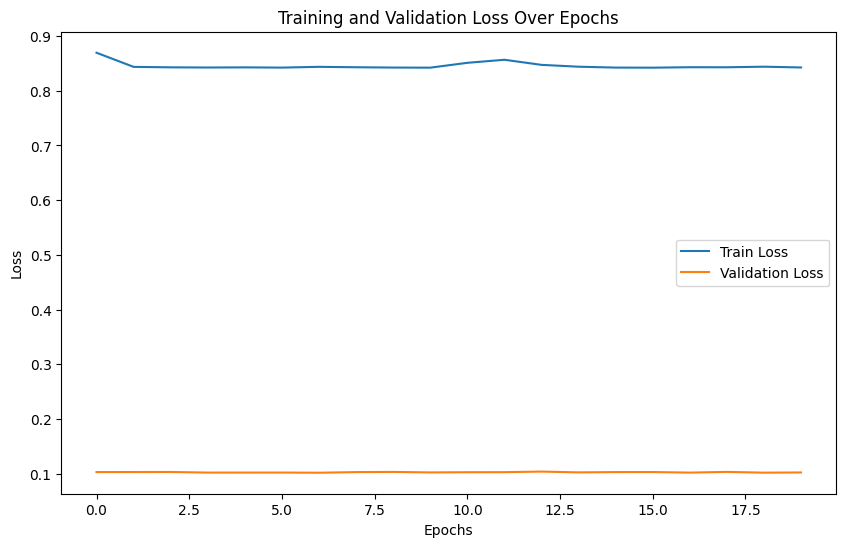

In [26]:
# Training and Validation Loss graph
plt.figure(figsize=(10, 6))
plt.plot(train_losses_vae_lstm, label='Train Loss')
plt.plot(validation_loss_vae_lstm, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.show()

4. Save the weights of the trained neural network that provides the best results. Check saving and loading models (PyTorch)

In [ ]:
### ADD YOUR CODE HERE ###
# Save the best model weights
# model(convolutional) or model_vae or model_vae_lstm 
#picking model 2(model_vae) as the best model 
torch.save(model_vae.state_dict(), "best_vae_model.pt")

## Step 3: Evaluation and analysis

1. Evaluate your best model on the test set. Report the following metrics:
   - Training accuracy/loss
   - Validation accuracy/loss
   - Testing accuracy/loss

In [28]:
### ADD YOUR CODE HERE ###
#Best model based on the trianing an dvalidation loss performance VAE Autoencoder model is the best.

model_vae.eval()
# model.eval()

# Evaluate Test Set
test_loss = []
predicted_reconstruction_errors = []  #reconstruction errors for threshold analysis
reconstructed_data = []
original_test_data =[]

correct_test = 0
total_test = 0
threshold = 0.5

# loss_function = nn.MSELoss()

with torch.no_grad():
  for data_value in test_loader:
    data_value = data_value[0]
    # print(data_value)
    # data_value = data_value.view(-1, input_dim)
    data_value = data_value.to(device)

    data_value = data_value.view(data_value.size(0), -1)

    # data_value = data_value.view(-1, 1, input_dim)

    # Forward pass
    recon_batch, mu, log_var = model_vae(data_value)
    # recon_batch = model(data_value)

    loss = loss_function(recon_batch, data_value, mu, log_var)
    # loss = loss_function(recon_batch, data_value)
    test_loss.append(loss.item())

    recon_error = torch.mean((data_value - recon_batch) ** 2, dim=1)
    predicted_reconstruction_errors.extend(recon_error.cpu().numpy())

    correct_test += (recon_error < threshold).sum().item()
    total_test += recon_error.size(0)

    original_test_data.append(data_value.cpu().numpy())
    reconstructed_data.append(recon_batch.cpu().numpy())



avg_test_loss = np.mean(test_loss)
print(f"Test Loss: {avg_test_loss:.4f}")

test_accuracy = correct_test / total_test
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 2.2103
Test Accuracy: 0.9165


2. Depending on your chosen dataset, report relevant metrics like:
   - Regression: Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), R-squared (coefficient of determination). Use sklearn.metrics.
   - Classification: Precision, Recall, F1-score.

In [29]:
### ADD YOUR CODE HERE ###
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

original_test_data = np.concatenate(original_test_data, axis=0)
reconstructed_data = np.concatenate(reconstructed_data, axis=0)

# Calculate regression metrics
mae = mean_absolute_error(original_test_data, reconstructed_data)
rmse = np.sqrt(mean_squared_error(original_test_data, reconstructed_data))
r2 = r2_score(original_test_data, reconstructed_data)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R²): {r2:.4f}")


Mean Absolute Error (MAE): 0.2701
Root Mean Squared Error (RMSE): 1.4981
R-squared (R²): -0.0019


3. Provide the following plots:
   - Plot training and validation accuracy/loss curves over epochs.
   - Plot the distribution of the reconstruction errors (i.e., differences between input and output data points).

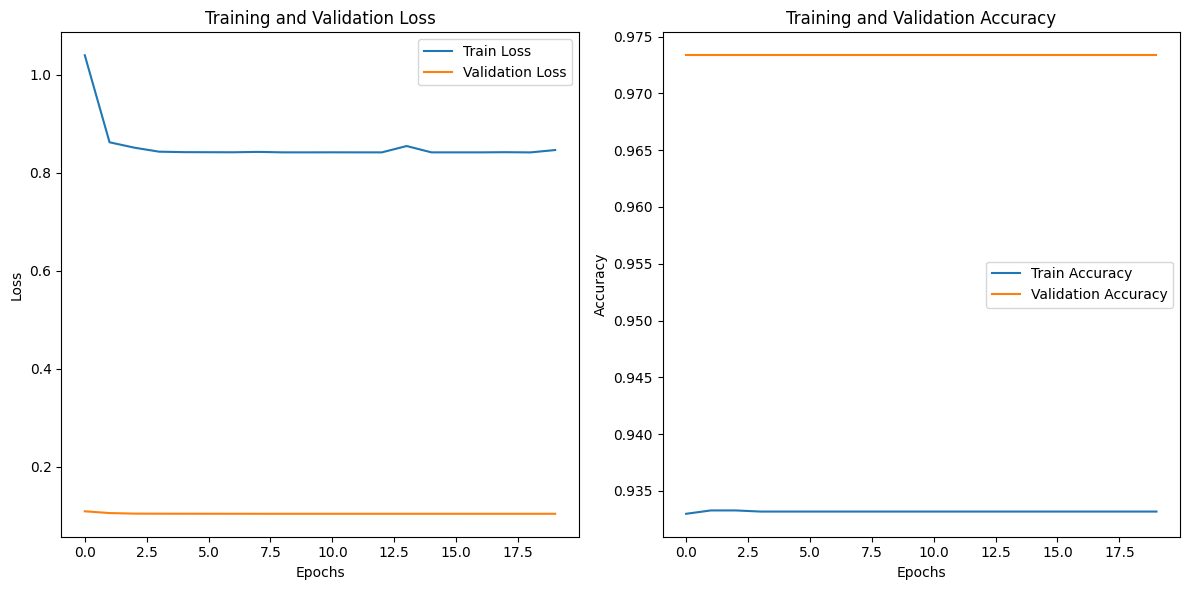

In [30]:
import matplotlib.pyplot as plt

# Plotting training and validation loss
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(train_losses_vae, label='Train Loss')
plt.plot(validation_loss_vae, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

# Plotting training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accuracy_vae, label='Train Accuracy')
plt.plot(validation_accuracy_vae, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()


plt.tight_layout()
plt.show()


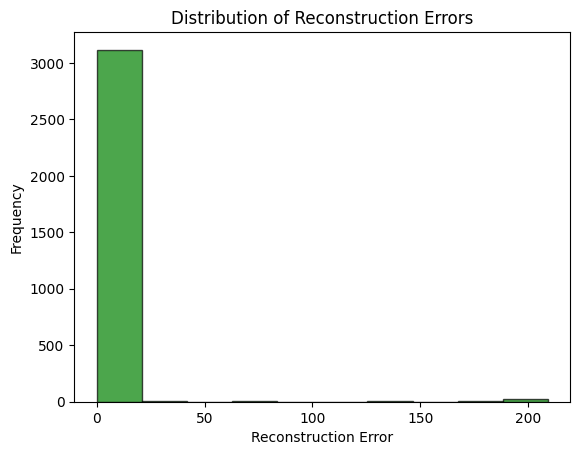

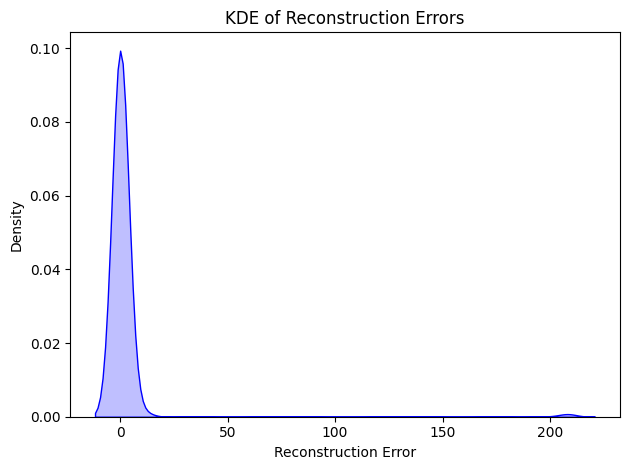

In [31]:
plt.hist(predicted_reconstruction_errors, bins=10, color='green', edgecolor='black', alpha=0.7)
plt.xlabel('Reconstruction Error')
plt.ylabel('Frequency')
plt.title('Distribution of Reconstruction Errors')
plt.show()

sns.kdeplot(predicted_reconstruction_errors, fill=True, color='blue')
plt.xlabel('Reconstruction Error')
plt.ylabel('Density')
plt.title('KDE of Reconstruction Errors')

plt.tight_layout()
plt.show()


Threshold (95th percentile): 1.0909342765808105
Number of anomalies detected: 158


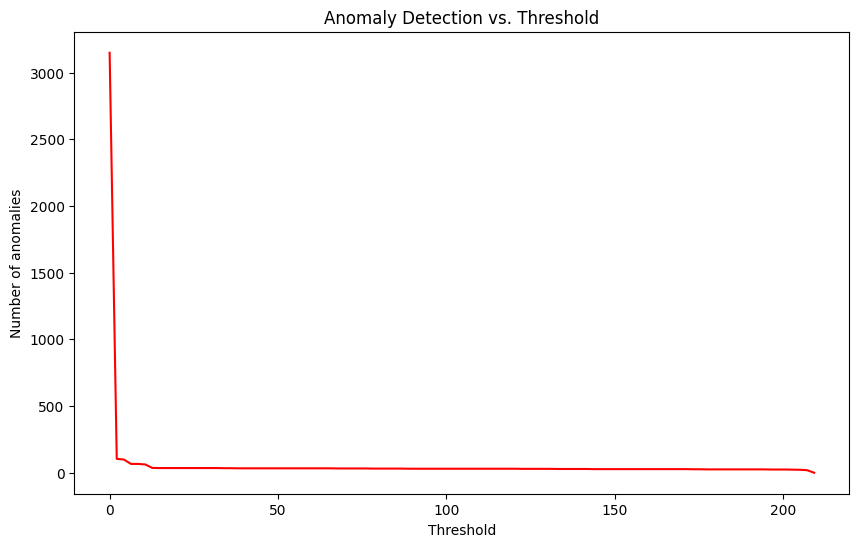

In [32]:
threshold_percentile = 95
threshold = np.percentile(predicted_reconstruction_errors, threshold_percentile)
print(f"Threshold (95th percentile): {threshold}")

# separate anomalies
anomalies = [error for error in predicted_reconstruction_errors if error > threshold]
print(f"Number of anomalies detected: {len(anomalies)}")

#Plot Anomalies vs. Threshold
thresholds = np.linspace(min(predicted_reconstruction_errors), max(predicted_reconstruction_errors), 100)
anomalies_count = [sum(np.array(predicted_reconstruction_errors) > t) for t in thresholds]

plt.figure(figsize=(10, 6))
plt.plot(thresholds, anomalies_count, label='Number of anomalies detected', color='red')
plt.xlabel('Threshold')
plt.ylabel('Number of anomalies')
plt.title('Anomaly Detection vs. Threshold')
plt.show()


4. Discuss and analyze:

   - Describe your final RNN/LSTM architecture in detail (number of layers, types of layers, hidden size, dropout rate, etc.).

<span style='color:green'>### YOUR ANSWER ###</span>

Based on the results from training and validation of the three models the best one which when tested with the test data returned good performance metrics is the **Model #2: Variational
Autoencoder (VAE)**. Listed below is the architecture setup:

- it is a fully connected model with encoder and decoder
- encoder has three fully connected layers starting with the input dimension to 256 hidden layers, 256 hidden layers to 128 hidden layers, last 128 layers to the latent dimension * 2. The multiplication by 2 is to use with mean and log_var.
- the encode method will get the input which passed through encoder to get h with the mean and the log variance.
- decoder reconstructs the input using three fully connected layers starting with latent dimension to 128, from 128 hidden layers to 256 and 256 to input dimension and then final output through sigmoid to get result.
- reparametrize method applies to the output at latent space using the mean log_var values to calculate the standard deviation and compares with z the normal distribution of mean and standard deviation.
- decode method  gets the z value from latent space  to reconstruct the original input
- forward method takes care of the forward pass. It takes input x and encodes it and gets mean and variance and the performs the reparameterization and then sends to decoder to reconstruct the input.

Also, we have the loss function setup which is slightly different for VAE autoencoder. There are two parts in the calculation of the loss value:
- Reconstruction Loss: use Mean squared error in our case since its sequential/continuous data, using the reconstruction value and the input.
- KL Divergence: using the KL divergence in the latent space with the mean and log variance values.

To summarize:
- encoder and decoder each have three layers
- in encoder start with hidden layers 256->128->latent_dim
- in decoder go from latent_dim->128-256->input_dim
- used linear fully connected layers


   - Discuss your results, referencing the metrics and visualizations. Did your model achieve the expected accuracy? What were the challenges? How did hyperparameter tuning affect performance? Are there any patterns in the errors (e.g., consistent under- or over-prediction)?

<span style='color:green'>### YOUR ANSWER ###</span>

**Training and Validation Metrics:**
Based on the training metrics and vizualization found under Training Model #2 we can note a few observations:
- The training loss intially starts are 1.0157 in epoch 1 and decreases and becomes 0.8421 by epoch 20. While the loss is decreasing the rate if improvement is slow. This shows model is learning but after a point begins to plateau as it reach an optimal state.
- Now here we look at the training accauracy we can see it remains at 93% through the training which shows model is learning well. However it is pretty consistent hence its not the best metric to just rely on since in autencoder the model trains differenctly comapred to a CNN or even an RNN/LSTM. Also accuracy is more suited for classification tasks
- Now for the trianing reconstruction loss is a bit high of 26.93, however this is something usually seen in a VAE autoencoder model as it tries to learn a distribution of the data and not memorize . And the loss does not see a lot of decrease but it is also based on reconstruction and regularization using KL divergence.

- Similarly lets compare the Validation metrics. Here the value decreases over 0.1066 to 0.1042 over the 20 epochs. There is not a big improvement which shows that the model is stable and not overfitting which is a good sign. The loss shows that the model is generalizing to unseen data.
- For the validation accuracy it is high at 97.34 through the epochs shows that model is generalizing again and remains consistent.
- Vadidation reconstruction loss  is stable and lower comapre to training with a value of 3.329 and that also shows that the model is reconstructing effectively with lesser error which is another good sign that the model is learning.


**Test Metrics:**
Moving to the test metrics for the model:

As we see:
Test Loss: 2.2102

Test Accuracy: 0.9165

- These two valeus show that the model performed well during training and validation with higher accuracy but also we can tell that the training vlauess could be higher due to slight overfitting that could be happening. So we can tell that a value of 91.65% for test data shows that the model has made some good generalizing but there can be slight chance of overfitting that will need to be addressed going further in this case.
- Similarly for the test loss the value is slightly higher than the training metrics. Now again here its finding it bit harder to geneeralize on the new data shows that the training data has chances of slight overfitting.


The other perfromance metrics on test data are:

Mean Absolute Error (MAE): 0.2701

Root Mean Squared Error (RMSE): 1.4981

R-squared (R²): -0.0019

- Here the MAE shows that the model's predictions are only off by 0.2701. This is pretty small but shows that model has small errors. Hoever this is still a goo indication that model has made good predicitons.
- RSME here is 1.4981, higher than MAE. Here this indicates that even though MAE is small the reconstruation error is slightlty big for some predicitions made on the test data.
- However now the R^2 error being negative is an issue. It kind of indicates that the predcitions are not matching the variance of the test data. And in turn this actually shows that model is not perfect fort this particular probelm and regulars adjustments or improving certian setup parameters.However this reuired futher review since the other performance metrics show that the model performs well and there is learning happenning.

- The threshold for anomaly we set at 95th with the reconstruction error distribution of 1.0909 and so any data points with reconstruction errors higher than the vlaue were flagged as anomalies. And the number of anomalies detected is 158.



**Challenges of the training:**
- Overfitting is a main issue to keep a lookout for here.  Here the training data is performs well but struggles sligthly on the test set. This shows signs of overfitting. Now this might be because of various parameters and the amount of data that is there.
- The recosntruction loss is also high during training which shows there can be further improvements to the model's architecture. However the model still predicts and reconstructs the input data correctly for some amount.



**Further improvements can include:**
- training with other learning rates using the learning rate scheduler.
- latent dimesnion can be increased
- number of layers can also be increases to see how the model performs and also trying other kinds of layers can help.
- adding dropout



Even though based on the perfrmance metrics we can see there is some signs of overfitting there is no exactly a clear pattern to it. We can see that there is high reconstruction error in certain cases which leads to show the anomalies. And that could signfiy that there is a chance that model has not learned the data distribution that well which is noticed in the negative R^2 value.

Overall there is some learning done by the model, but also there is room for improvement based on test data metrics. And even though we have used accuarcy as a measurement to understand the model it is not exactly a metric for an autoencoder since accuarcy is much better at classification tasks and autoencoder is a generative model. So here the better metrics are the loss and reconstruction values that are taken into consideration.


   - Discuss the strengths and limitations of using autoencoders for anomaly detection.

<span style='color:green'>### YOUR ANSWER ###</span>

**Strengths:**

- Used as an unsupervised learning method where they don't require the labelled data to learn patterns. The model learns to reconstruct the input data that is shared and gives an deviation from the normal value.
- Autoencoder such as the VAE, Convolutional are helpful in capturing high complex and non linear data distributions. And it helps to find anomaly detection in datasets be it with images, time-series or multi-dimensional data.
- It can be used for different kinds of data

**Limitations:**
- Sensitive to data normalization and preprocessing. That is its important how the data is preprocessed and what kind of feature engineering is chosen to train the autoencoder. Poor preprocessing can affect the performance and anomaly detection.
- Another issue is autoencoders are trained to reconstruct input data so if the model gets data that is different from data it has seen then it might find it hard to reconstruct and capture the anomaly.
- Can have high false negative or false positive values if the anomalies are diverse or limited.
- overfitting with complex models.
- performance is affected with imbalanced datasets. So model might learn well but find it harder to reconstruct the data or find outliers.

5. References. Include details on all the resources used to complete this part, e.g. links to datasets, research papers or articles, code examples or tutorials you referred.

<span style='color:green'>### YOUR ANSWER ###</span>

References:



*  https://arxiv.org/pdf/2003.05991
*   https://www.numenta.com/assets/pdf/numenta-anomaly-benchmark/NAB-Business-Paper.pdfhttps://www.numenta.com/assets/pdf/
*   https://medium.com/@syed_hasan/autoencoders-theory-pytorch-implementation-a2e72f6f7cb7
*   https://medium.com/machine-learning-researcher/auto-encoder-d942a29c9807
*   https://www.geeksforgeeks.org/implementing-an-autoencoder-in-pytorch/
*   https://medium.com/@sofeikov/implementing-variational-autoencoders-from-scratch-533782d8eb95
*   https://medium.com/@rekalantar/variational-auto-encoder-vae-pytorch-tutorial-dce2d2fe0f5f
*   https://medium.com/@amit25173/a-deep-dive-into-variational-autoencoders-with-pytorch-6feac8e1c25e
*   https://github.com/matanle51/LSTM_AutoEncoder/blob/master/models/LSTMAE.py
*   https://medium.com/@weidagang/demystifying-anomaly-detection-with-autoencoder-neural-networks-1e235840d879#:~:text=In%20the%20context%20of%20anomaly,will%20likely%20reconstruct%20it%20poorly.
*   https://www.geeksforgeeks.org/how-to-use-pytorch-for-anomaly-detection/
*   https://www.geeksforgeeks.org/implement-convolutional-autoencoder-in-pytorch-with-cuda/
*   https://discuss.pytorch.org/t/cross-entropy-loss-target-size-and-output-size-mismatch/99031/13

*   https://pytorch.org/tutorials/beginner/introyt/trainingyt.html








